In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [88]:
insurance = pd.read_csv(r"C:\Users\Divine\Downloads\insurance.csv", encoding='latin-1')

In [89]:
insurance[insurance.duplicated()]


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [90]:
insurance = insurance.drop_duplicates()

In [91]:
display(insurance.head())
display(insurance.info())
insurance.describe()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


None

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [92]:
insurance['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [93]:
insurance['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [94]:
insurance['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [95]:
insurance.groupby('sex')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578844,11128.703801,1607.5101,4885.158700,9412.9625,14454.691825,63770.42801
male,675.0,13974.998864,12971.958663,1121.8739,4654.022675,9377.9047,19006.685500,62592.87309


In [96]:
insurance.groupby("smoker")["charges"].describe()

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1063.0,8440.660307,5992.973800,1121.8739,3988.883500,7345.72660,11363.019100,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


In [97]:

insurance.groupby('region')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.384516,11255.803066,1694.7964,5194.322288,10057.652025,16687.364100,58571.07448
northwest,324.0,12450.840844,11073.125699,1621.3402,4733.635288,8976.977250,14788.747863,60021.39897
southeast,364.0,14735.411438,13971.098589,1121.8739,4440.886200,9294.131950,19526.286900,63770.42801
southwest,325.0,12346.937377,11557.179101,1241.5650,4751.070000,8798.593000,13462.520000,52590.82939


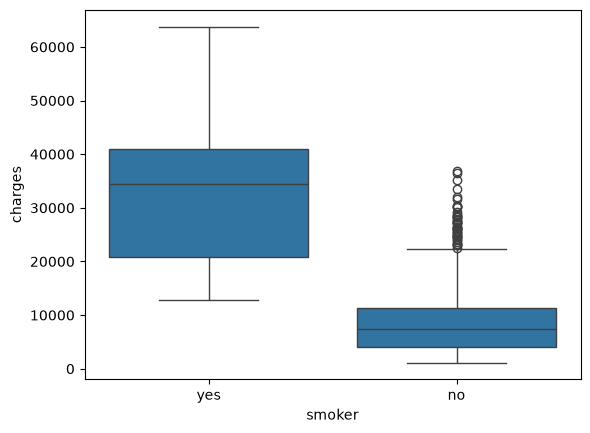

In [98]:
sns.boxplot(data= insurance, x = "smoker", y = "charges")
plt.show()

In [99]:
insurance.groupby(['sex', 'smoker'])['charges'].describe()

count          mean           std         min           25%  \
sex    smoker                                                                
female no      547.0   8762.297300   6060.775970   1607.5101   4265.599100   
       yes     115.0  30678.996276  11907.536381  13844.5060  19696.432100   
male   no      516.0   8099.700161   5907.000174   1121.8739   3684.907500   
       yes     159.0  33042.005975  11202.670862  12829.4551  21241.526875   

                        50%          75%          max  
sex    smoker                                          
female no       7639.417450  11786.16660  36910.60803  
       yes     28950.469200  40918.31450  63770.42801  
male   no       6986.101975  10960.85900  32108.66282  
       yes     36085.219000  41797.58905  62592.87309

In [100]:
insurance.groupby(['region', 'smoker'])['charges'].describe()

count          mean           std         min           25%  \
region    smoker                                                                
northeast no      257.0   9165.531672   6157.196439   1694.7964   4438.263400   
          yes      67.0  29673.536473  11589.559770  12829.4551  19881.400425   
northwest no      266.0   8582.467101   6125.331366   1621.3402   4201.807987   
          yes      58.0  30192.003182  11413.827702  14711.7438  20834.130337   
southeast no      273.0   8032.216309   6137.329758   1121.8739   3471.409600   
          yes      91.0  34844.996824  11324.766536  16577.7795  23155.105450   
southwest no      267.0   8019.284513   5489.514421   1241.5650   3947.026500   
          yes      58.0  32269.063494  11270.279593  13844.5060  20396.042022   

                           50%           75%          max  
region    smoker                                           
northeast no       8342.908750  11938.255950  32108.66282  
          yes     28101.333050  39576.950850  58571.07448  
northwest no       7259.232050  11355.802575  33471.97189  
          yes     27488.996475  39918.948975  60021.39897  
southeast no       6652.528800  10982.501300  36580.28216  
          yes     37484.449300  43391.859400  63770.42801  
southwest no       7348.142000  11017.990500  36910.60803  
          yes     35165.256500  39809.292750  52590.82939